# Random Forest: predicción de aprobación de préstamos

En este notebook analizamos un dataset de **aprobación de préstamos** y construimos un modelo Random Forest para predecir si un préstamo será aprobado o no.

Incluye:

1. Exploración de los datos (EDA)
2. Visualización de variables numéricas y categóricas
3. Preparación y codificación de variables
4. División en conjuntos de entrenamiento y test
5. Entrenamiento del modelo
6. Evaluación del modelo

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.tree import DecisionTreeClassifier, plot_tree

### Carga de datos

In [11]:
df=pd.read_csv("https://raw.githubusercontent.com/Jorgeprevi/ML_bootcamp_2026/refs/heads/main/random_forest/loan_data.csv")

## Exploración rápida del dataset

El dataset consta de varias features numéricas y categóricas:


- **person_age**:	edad del aplicante

- **person_gender**:	género

- **person_education**:	mayor nivel de educación

- **person_income**:	saldo anual

- **person_emp_exp**:	años de experiencia laboral

- **person_home_ownership**:	Status de propiedad de casa

- **loan_amnt**:	cantidad del préstamo requerido

- **loan_intent**:	propósito del préstamo

- **loan_int_rate**:	tipo de interés

- **loan_percent_income**:	préstamo como porcentaje del salario anual

- **cb_person_cred_hist_length**:	años de historial crediticio

- **credit_score**:	credit score del aplicante

- **previous_loan_defaults_on_file**:	defaults en préstamos anteriores (Yes/No)

- **loan_status**:	Resultado del estado del préstamo (1 = approved, 0 = rejected)

In [12]:
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [13]:
df.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


## Exploración de variables numéricas

Antes de entrenar un modelo de machine learning es importante **entender la distribución de los datos**.  
En particular, analizaremos cómo se distribuyen las variables numéricas del dataset.

Esto nos permite:

- Detectar **valores extremos (outliers)**
- Identificar **asimetrías o distribuciones sesgadas**
- Entender el **rango de valores** de cada variable
- Detectar posibles **problemas de calidad de datos**

Para ello generamos **histogramas** de las principales variables numéricas relacionadas con el perfil de la persona y las características del préstamo.

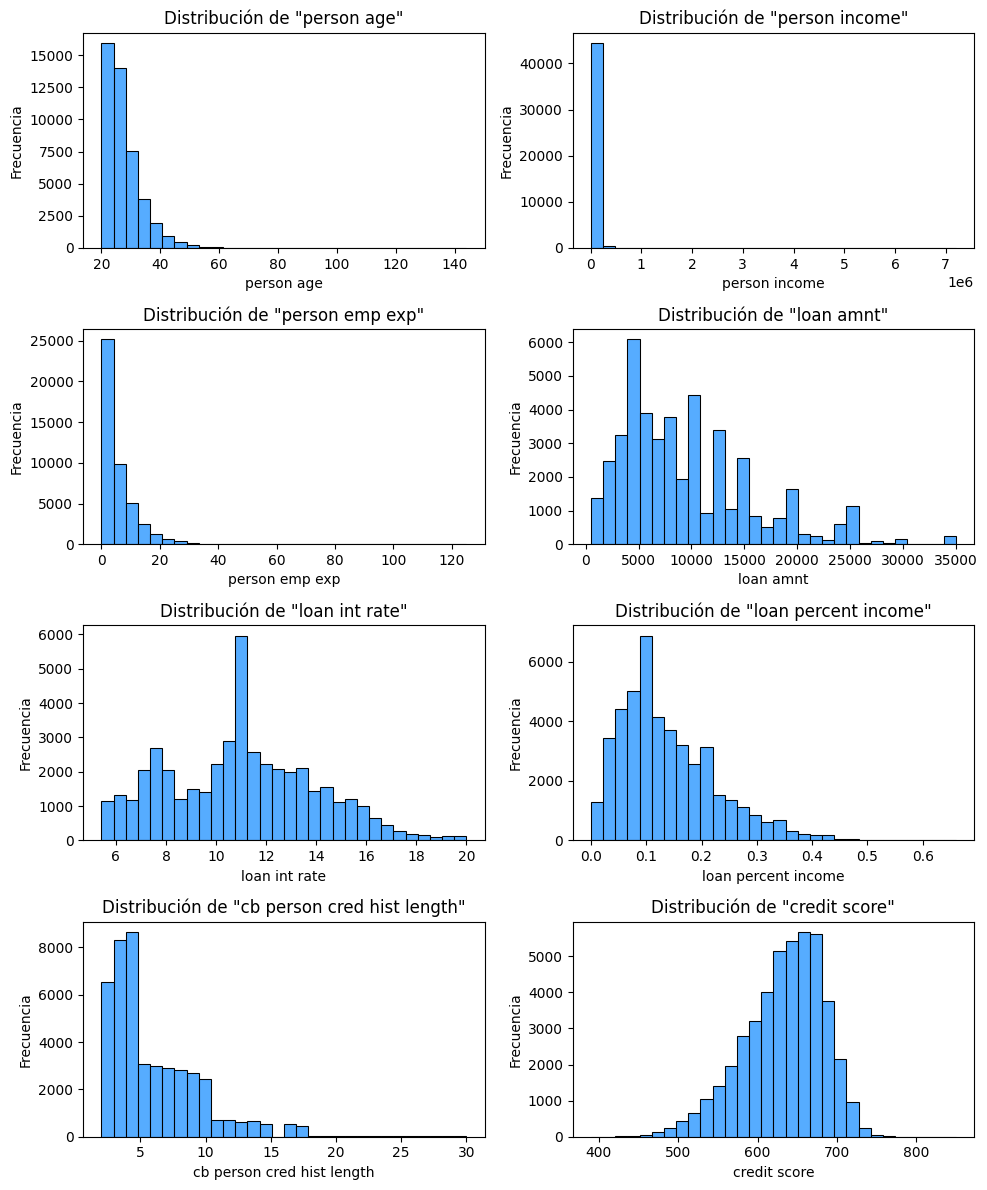

In [14]:
def plot_distribuciones(data, columns):
    plt.figure(figsize=(10, 12))  
    
    for i, column in enumerate(columns, 1):
        plt.subplot(4, 2, i)  
        sns.histplot(data[column], kde=False, bins=30, color='dodgerblue')
        plt.title(f'Distribución de \"{column.replace("_", " ")}\"')
        plt.xlabel(column.replace('_', ' '))
        plt.ylabel('Frecuencia')
    
    plt.tight_layout()
    plt.show()

columnas_analisis = ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score']

plot_distribuciones(df, columnas_analisis)

## Exploración de variables categóricas

Ahora, analizamos la distribución de variables categóricas, como el género de la persona o el propósito del préstamo.

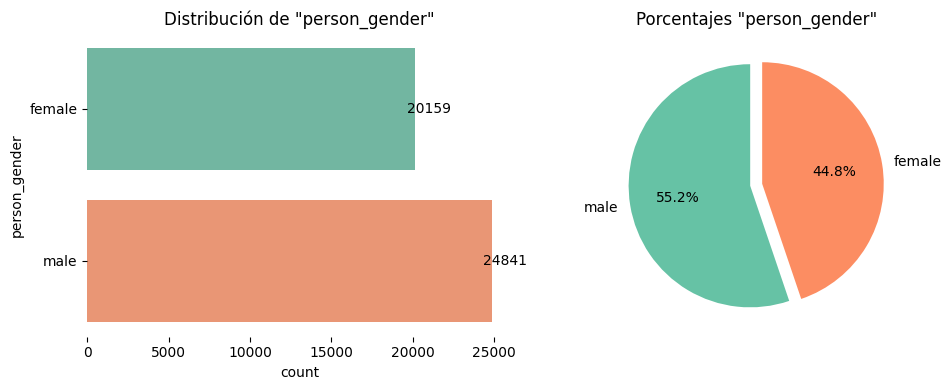

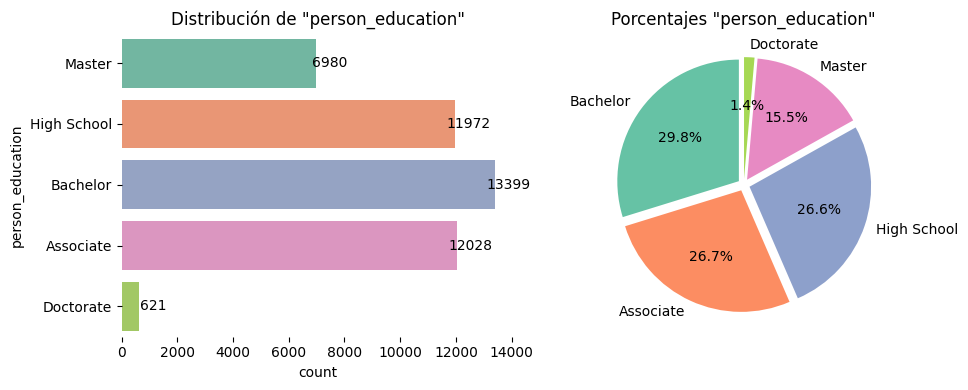

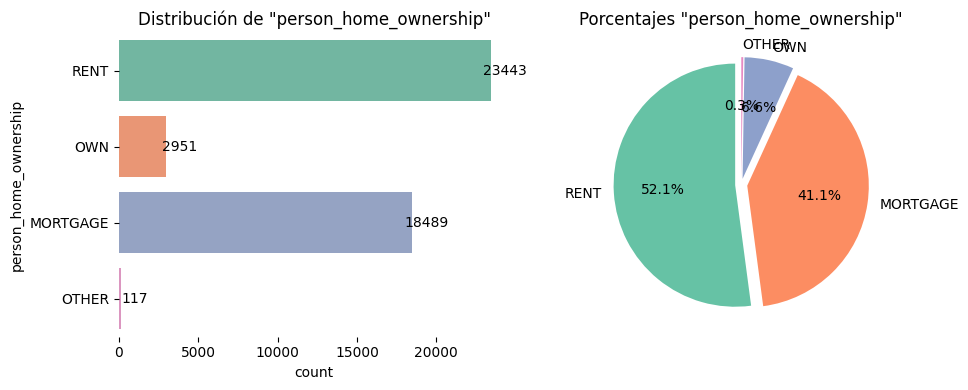

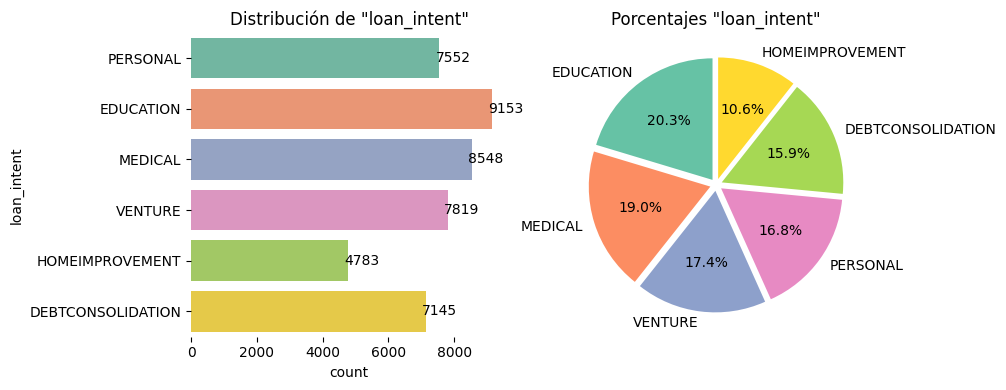

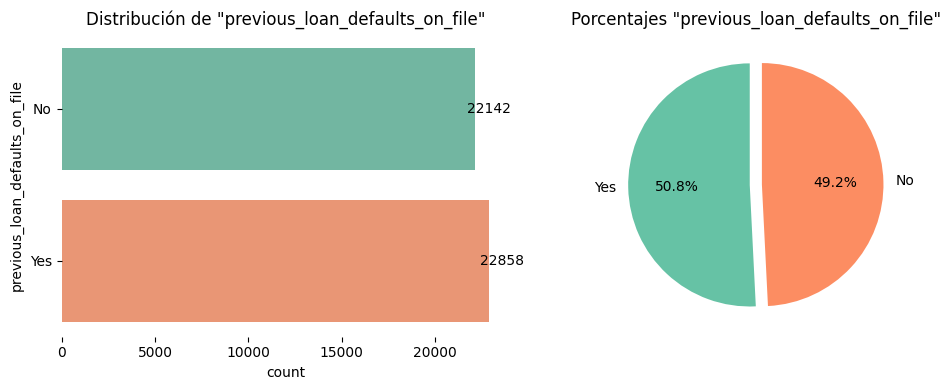

In [15]:
def plot_distribuciones_categor(column_name, data=df):
    plt.figure(figsize=(10, 4))
    
    plt.subplot(1, 2, 1)
    sns.countplot(y=column_name, data=df, palette='Set2', hue=column_name)  
    plt.title(f'Distribución de \"{column_name}\"')
    
    ax = plt.gca()
    for p in ax.patches:
        ax.annotate(f'{int(p.get_width())}', (p.get_width(), p.get_y() + p.get_height() / 2), 
                    ha='center', va='center', xytext=(10, 0), textcoords='offset points')
    
    sns.despine(left=True, bottom=True)
    
    plt.subplot(1, 2, 2)
    df[column_name].value_counts().plot.pie(autopct='%1.1f%%',  colors=sns.color_palette('Set2'), startangle=90, explode=[0.05]*df[column_name].nunique())
    plt.title(f'Porcentajes \"{column_name}\"')
    plt.ylabel('')  
    
    plt.tight_layout()
    plt.show()

vars_categoricas = ['person_gender', 'person_education', 'person_home_ownership', 'loan_intent', 'previous_loan_defaults_on_file']
for var in vars_categoricas:
    plot_distribuciones_categor(var)

## Preprocesamiento

En este paso realizamos dos tipos de codificación:

1. Label Encoding: se utiliza para variables categóricas binarias, convirtiendo cada categoría en un valor numérico (por ejemplo, 0, 1, 2, ...).

2. One-Hot Encoding: para variables con múltiples categorías utilizamos **one-hot encoding**, que crea una nueva columna binaria para cada categoría.

In [16]:
le = LabelEncoder()
df['person_gender'] = le.fit_transform(df['person_gender'])
df['previous_loan_defaults_on_file'] = le.fit_transform(df['previous_loan_defaults_on_file'])

# OHE
df = pd.get_dummies(df, columns=['person_education', 'person_home_ownership', 'loan_intent'], drop_first=True,dtype=int)

De cara al entrenamiento, separamos entre training y test sets

In [ ]:
y = df['loan_status']

X = df.drop('loan_status', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Entrenamiento del modelo Random Forest

In [18]:
tree = DecisionTreeClassifier(
    random_state=42,
    class_weight='balanced'
)

tree.fit(X_train, y_train)

y_train_pred_tree = tree.predict(X_train)
y_test_pred_tree = tree.predict(X_test)

print("ÁRBOL DE DECISIÓN")
print("Accuracy train:", accuracy_score(y_train, y_train_pred_tree))
print("Accuracy test: ", accuracy_score(y_test, y_test_pred_tree))
print()
print(classification_report(y_test, y_test_pred_tree))

ÁRBOL DE DECISIÓN
Accuracy train: 1.0
Accuracy test:  0.9012222222222223

              precision    recall  f1-score   support

           0       0.93      0.94      0.94      6990
           1       0.78      0.77      0.78      2010

    accuracy                           0.90      9000
   macro avg       0.86      0.86      0.86      9000
weighted avg       0.90      0.90      0.90      9000



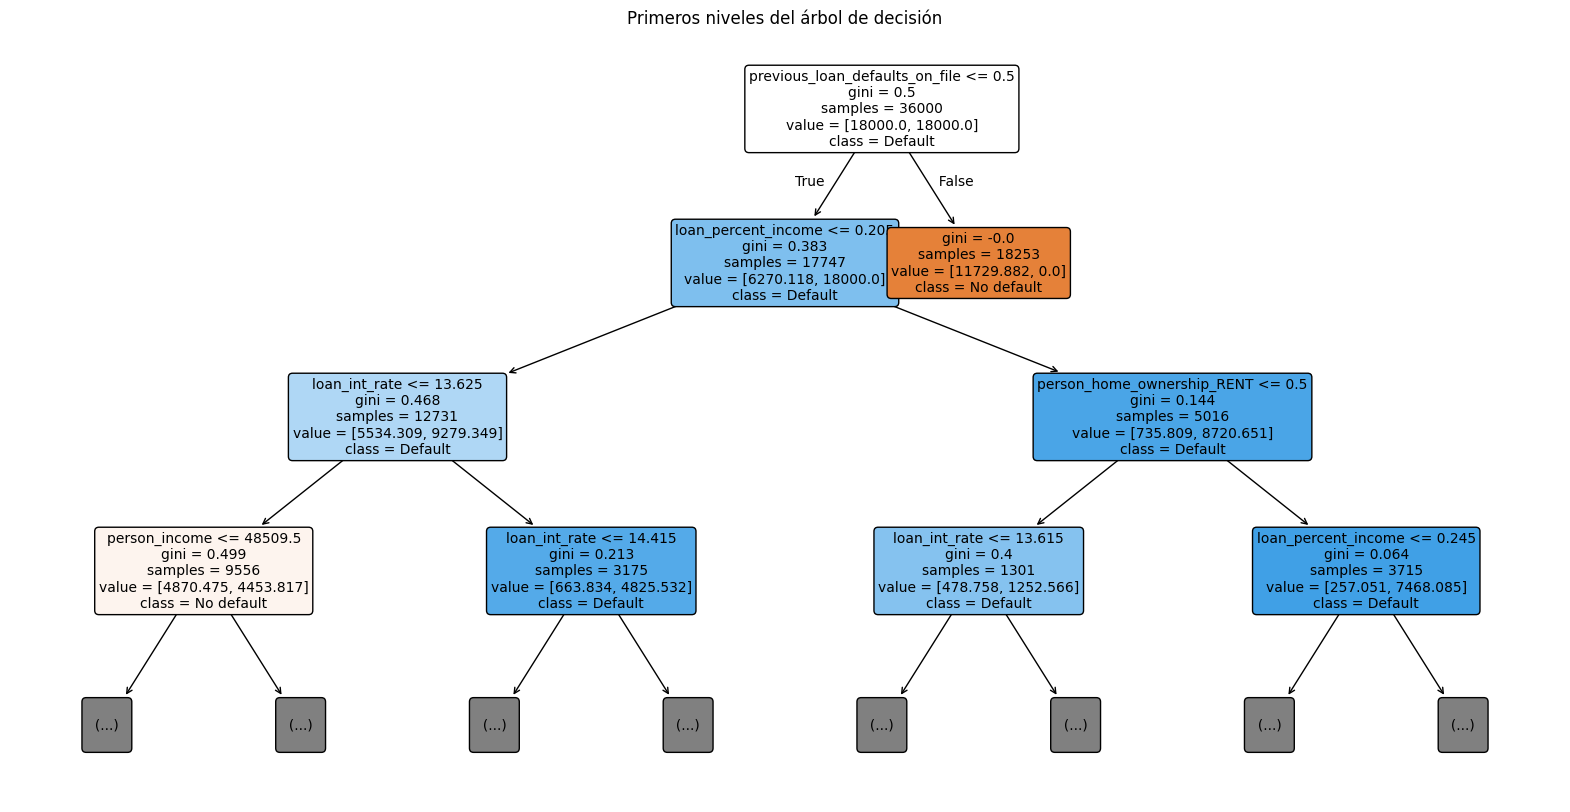

In [19]:
plt.figure(figsize=(20, 10))
plot_tree(
    tree,
    feature_names=X.columns,
    class_names=['No default', 'Default'],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=10
)
plt.title("Primeros niveles del árbol de decisión")
plt.show()


In [20]:
print("Profundidad del árbol:", tree.get_depth())
print("Número de hojas:", tree.get_n_leaves())


Profundidad del árbol: 33
Número de hojas: 2725


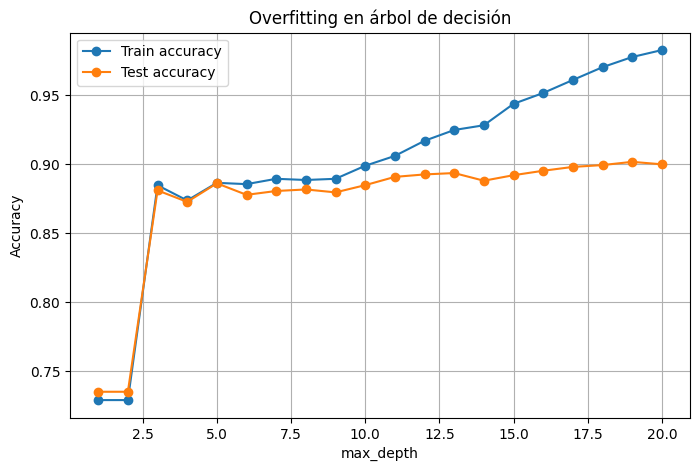

In [21]:
depths = range(1, 21)
train_acc = []
test_acc = []

for d in depths:
    tree_d = DecisionTreeClassifier(
        max_depth=d,
        random_state=42,
        class_weight='balanced'
    )
    tree_d.fit(X_train, y_train)
    
    train_acc.append(tree_d.score(X_train, y_train))
    test_acc.append(tree_d.score(X_test, y_test))

plt.figure(figsize=(8, 5))
plt.plot(depths, train_acc, marker='o', label='Train accuracy')
plt.plot(depths, test_acc, marker='o', label='Test accuracy')
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Overfitting en árbol de decisión")
plt.legend()
plt.grid(True)
plt.show()


In [39]:
features_2d = ['credit_score', 'loan_percent_income']  # cambia por dos numéricas de tu dataset
X_2d = df[features_2d]
y_2d = df['loan_status']

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X_2d, y_2d, test_size=0.2, random_state=42, stratify=y_2d
)

tree_2d = DecisionTreeClassifier(
    random_state=42,
    class_weight='balanced',
    max_depth=None
)
tree_2d.fit(X2_train, y2_train)

print("Accuracy train (2D):", tree_2d.score(X2_train, y2_train))
print("Accuracy test  (2D):", tree_2d.score(X2_test, y2_test))


Accuracy train (2D): 0.7811111111111111
Accuracy test  (2D): 0.6805555555555556


In [42]:
def plot_decision_boundary(model, X, y, feature_names, title):
    x_min, x_max = X.iloc[:, 0].min() - 0.1, X.iloc[:, 0].max() + 0.1
    y_min, y_max = X.iloc[:, 1].min() - 0.1, X.iloc[:, 1].max() + 0.1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = pd.DataFrame(
        np.c_[xx.ravel(), yy.ravel()],
        columns=feature_names
    )
    Z = model.predict(grid).reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y, edgecolor='k', alpha=0.7)
    plt.xlabel(feature_names[0])
    plt.ylabel(feature_names[1])
    plt.title(title)
    plt.show()


In [44]:
tree_shallow = DecisionTreeClassifier(
    max_depth=2,
    random_state=42,
    class_weight='balanced'
)
tree_deep = DecisionTreeClassifier(
    max_depth=None,
    random_state=42,
    class_weight='balanced'
)

tree_shallow.fit(X2_train, y2_train)
tree_deep.fit(X2_train, y2_train)

print("Shallow tree - train:", tree_shallow.score(X2_train, y2_train))
print("Shallow tree - test: ", tree_shallow.score(X2_test, y2_test))
print()
print("Deep tree - train:", tree_deep.score(X2_train, y2_train))
print("Deep tree - test: ", tree_deep.score(X2_test, y2_test))


Shallow tree - train: 0.8232222222222222
Shallow tree - test:  0.8282222222222222

Deep tree - train: 0.7811111111111111
Deep tree - test:  0.6805555555555556


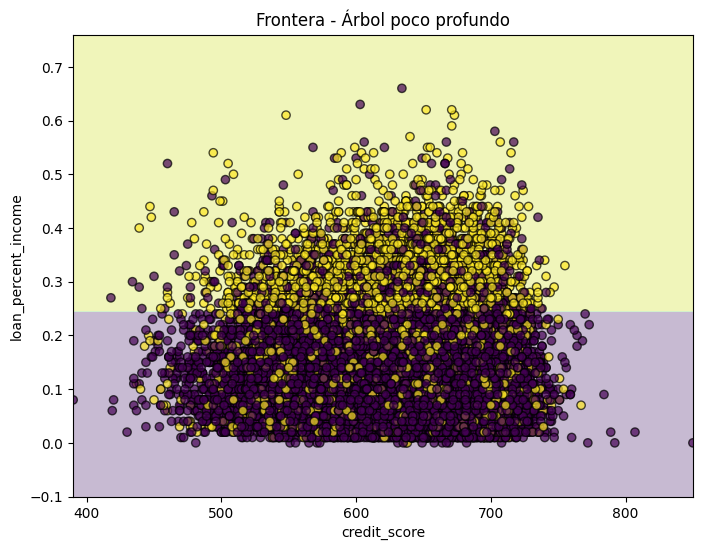

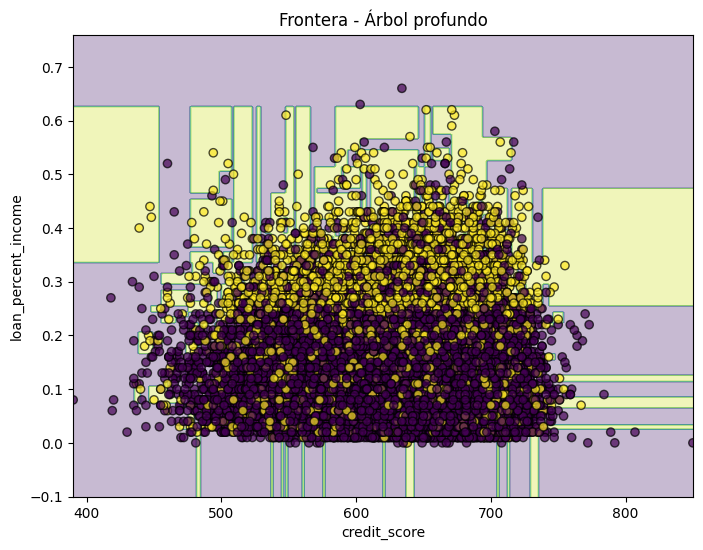

In [45]:
plot_decision_boundary(
    tree_shallow,
    X2_train,
    y2_train,
    features_2d,
    "Frontera - Árbol poco profundo"
)

plot_decision_boundary(
    tree_deep,
    X2_train,
    y2_train,
    features_2d,
    "Frontera - Árbol profundo"
)


Procedemos al ajuste, configurando algunos parámetros importantes:

- `n_estimators=100`: número de árboles en el bosque
- `class_weight='balanced'`: ajusta automáticamente el peso de cada clase para manejar posibles **datasets desbalanceados**

In [27]:
rf = RandomForestClassifier(random_state=42,class_weight='balanced', n_estimators=100)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

## Evaluación inicial del modelo

Una vez entrenado el modelo, evaluamos su rendimiento utilizando varias métricas de clasificación:

- **Accuracy**: proporción de predicciones correctas
- **Precision**: de los préstamos predichos como impagados, cuántos lo son realmente
- **Recall**: de los préstamos realmente impagados, cuántos detecta el modelo
- **F1-score**: media armónica entre precisión y recall

In [28]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.9295555555555556

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.98      0.96      6990
           1       0.90      0.77      0.83      2010

    accuracy                           0.93      9000
   macro avg       0.92      0.87      0.89      9000
weighted avg       0.93      0.93      0.93      9000



## Matriz de confusión

Obtenemos la matriz de confusión, que nos muestra:

- **True Positives (TP)**: préstamos correctamente clasificados como impagados
- **True Negatives (TN)**: préstamos correctamente clasificados como pagados
- **False Positives (FP)**: préstamos clasificados como impagados que en realidad no lo son
- **False Negatives (FN)**: préstamos impagados que el modelo no detectó

Este análisis es especialmente importante en problemas financieros, donde **los falsos negativos pueden ser costosos**.

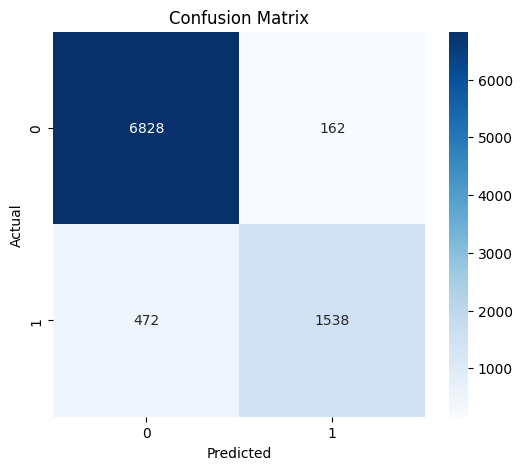

In [29]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

## Importancia de variables

Una ventaja de los modelos basados en árboles es que permiten estimar la **importancia de cada variable** en las predicciones.

La importancia indica **cuánto contribuye cada feature a reducir el error del modelo** durante la construcción de los árboles.

Esto nos ayuda a:

- Interpretar el modelo
- Identificar las variables más relevantes
- Detectar posibles variables irrelevantes

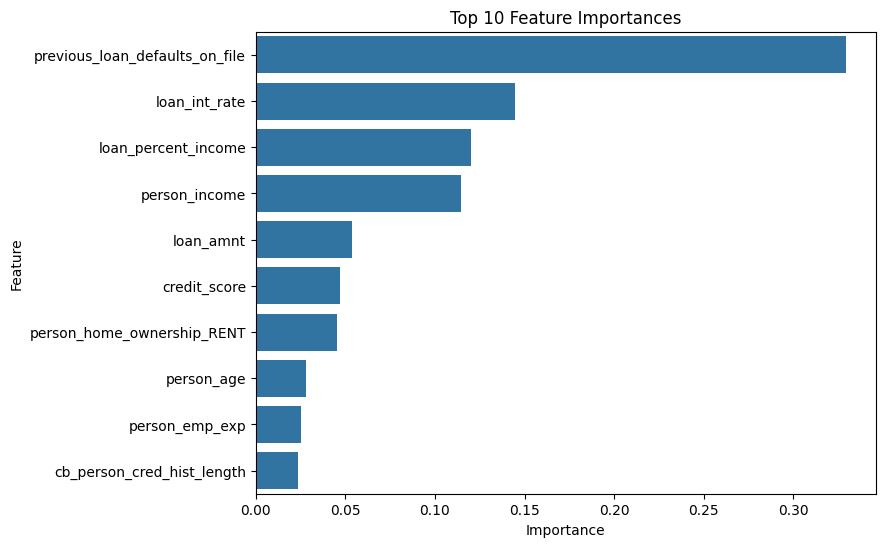

In [30]:
import pandas as pd

feature_importances = pd.Series(rf.feature_importances_, index=X.columns)
feature_importances = feature_importances.sort_values(ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x=feature_importances[:10], y=feature_importances.index[:10])

plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()